<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [ ]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

import requests
import time

### Datos
Descargo el mismo libro que usé en el Desafío 2 (Moby Dick)

In [ ]:
# Descargo el libro
url = "https://www.gutenberg.org/cache/epub/2701/pg2701.txt"

response = requests.get(url)
text = response.text

# Saco encabezado y pie de Project Gutenberg

start_marker = "Call me Ishmael. "
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK MOBY DICK; OR, THE WHALE ***"

start = text.find(start_marker)
end = text.find(end_marker)

if start != -1:
    text_clean = text[start + len(start_marker):]
else:
    text_clean = text

if end != -1:
    text_clean = text_clean[:text_clean.find(end_marker)]

article_text = text_clean.strip()

In [ ]:
# reemplazo caracteres especiales por espacios

article_text = article_text.replace('\r\n', ' ')
article_text = article_text.replace('\n', ' ')

# pasar todo el texto a minúscula

article_text = article_text.lower()

# recorto en 360000 caracteres para que entre en la RAM
article_text = article_text[:360000]

In [ ]:
# en article text se encuentra el texto de todo el libro
article_text[0: 1000]

'some years ago—never mind how long precisely—having little or no money in my purse, and nothing particular to interest me on shore, i thought i would sail about a little and see the watery part of the world. it is a way i have of driving off the spleen and regulating the circulation. whenever i find myself growing grim about the mouth; whenever it is a damp, drizzly november in my soul; whenever i find myself involuntarily pausing before coffin warehouses, and bringing up the rear of every funeral i meet; and especially whenever my hypos get such an upper hand of me, that it requires a strong moral principle to prevent me from deliberately stepping into the street, and methodically knocking people’s hats off—then, i account it high time to get to sea as soon as i can. this is my substitute for pistol and ball. with a philosophical flourish cato throws himself upon his sword; i quietly take to the ship. there is nothing surprising in this. if they but knew it, almost all men in their d

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [ ]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [ ]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [ ]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [ ]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

60

In [ ]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [ ]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [ ]:
tokenized_text[:10]

[27, 21, 22, 38, 45, 33, 38, 40, 42, 27]

### Organizando y estructurando el dataset

In [ ]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [ ]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [ ]:
tokenized_sentences_val = [
    val_text[init*max_context_size:(init+1)*max_context_size]
    for init in range(num_val)
]

In [ ]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [ ]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [ ]:
X.shape

(323900, 100)

In [ ]:
X[0,:10]

array([27, 21, 22, 38, 45, 33, 38, 40, 42, 27])

In [ ]:
y[0,:10]

array([21, 22, 38, 45, 33, 38, 40, 42, 27, 45])

In [ ]:
vocab_size = len(chars_vocab)

# Perplejidad

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` .
    '''

    #def __init__(self, val_data, history_ppl,patience=5):
    #ajusto para que guarde modelos con nombres distintos
    def __init__(self, val_data, history_ppl, patience=5, model_name="my_model.keras"):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data
      self.history_ppl = history_ppl #agrego para que almacene los datso de cada modelo

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience
      self.model_name = model_name #agrego para que guarde modelos con nombres distintos

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save(self.model_name)
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Generación de secuencias

In [ ]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

###  Beam search y muestreo aleatorio

In [ ]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [ ]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

# SimpleRNN

### Definir el modelo

In [ ]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [ ]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 60)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        52,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 60)       │        12,060 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,260 (251.02 KB)

 Trainable params: 64,260 (251.02 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [ ]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl_simple = []

start_time = time.time() #agrego para medir el tiempo

hist_simple = model.fit(
    X,
    y,
    epochs=20,
    callbacks=[
        PplCallback(
            tokenized_sentences_val,
            history_ppl_simple,
            patience=5,
            model_name="model_SimpleRNN.keras"
        )
    ],
    batch_size=256
)

end_time = time.time()

time_simple = end_time - start_time

print(f"Tiempo SimpleRNN: {time_simple:.2f} segundos")
print(f"Tiempo SimpleRNN: {time_simple/60:.2f} minutos")

Epoch 1/20
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.4816
 mean perplexity: 7.842416477203369 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - loss: 2.2592
Epoch 2/20
1265/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9938
 mean perplexity: 6.89473979473114 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - loss: 1.9579
Epoch 3/20
1265/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.8835
 mean perplexity: 6.5152320835325455 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - loss: 1.8695
Epoch 4/20
1263/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.8359
 mean perplexity: 6.3873669902483625 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - loss: 1.8277
Epoch 5/20
1264/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.8083
 mean perplexity: 6.333303484651777 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - loss: 1.8033
Epoch 6/20
1263/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7901
 mea

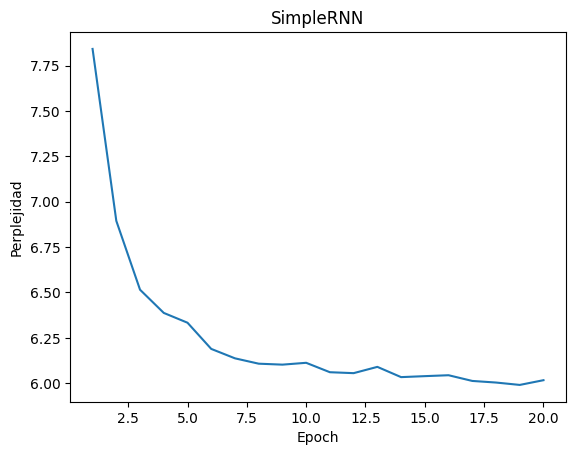

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

epoch_count = range(1, len(history_ppl_simple) + 1)

sns.lineplot(x=epoch_count, y=history_ppl_simple)
plt.xlabel("Epoch")
plt.ylabel("Perplejidad")
plt.title("SimpleRNN")
plt.show()

### Generación de secuencias

In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model("model_SimpleRNN.keras")

In [ ]:
input_text='whenever it is a damp, drizzly'

generate_seq(model, input_text, max_length=max_context_size, n_words=60)

'whenever it is a damp, drizzly and something a stranger of the same to the same to the sam'

###  Beam search y muestreo aleatorio

In [ ]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="whenever it is a damp, drizzly")

In [ ]:
salidas[0]

array([43,  2, 38, 37, 38, 10, 38, 42, 45,  9, 17, 45,  9, 27, 45, 40, 45,
        8, 40, 22, 49,  7, 45,  8, 42,  9,  5,  5, 44, 33,  7, 45, 40, 37,
        8, 45, 17,  2, 38, 42, 38, 45, 43, 40, 27, 45, 17,  2, 38, 45, 43,
        2, 40, 44, 38,  7, 45, 40, 37,  8, 45, 17,  2, 38, 42, 38, 45, 43,
       40, 27, 45, 17,  2, 38, 45, 43,  2, 40, 44, 38,  7, 45, 40, 37,  8,
       45, 17,  2, 38, 45])

In [ ]:
# veamos las salidas
decode(salidas[0])

'whenever it is a damp, drizzly, and there was the whale, and there was the whale, and the '

# LSTM

### Definir el modelo

In [ ]:
from keras.layers import TimeDistributed, CategoryEncoding, LSTM, Dense
from keras.models import Sequential

model = Sequential()

model.add(
    TimeDistributed(
        CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
        input_shape=(None, 1)
    )
)

model.add(
    LSTM(
        200,
        return_sequences=True,
        dropout=0.1,
        recurrent_dropout=0.0 #Bajo el recurrent dropout para que tarde un poco menos
    )
)

model.add(Dense(vocab_size, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 60)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       208,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 60)       │        12,060 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,860 (862.73 KB)

 Trainable params: 220,860 (862.73 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [ ]:
history_ppl_lstm = []

start_time = time.time()

hist_lstm = model.fit(
    X,
    y,
    epochs=20,
    callbacks=[
        PplCallback(
            tokenized_sentences_val,
            history_ppl_lstm,
            patience=5,
            model_name="model_LSTM.keras"
        )
    ],
    batch_size=256
)

end_time = time.time()

time_lstm = end_time - start_time

print(f"Tiempo LSTM: {time_lstm:.2f} segundos")
print(f"Tiempo LSTM: {time_lstm/60:.2f} minutos")

Epoch 1/20
1265/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.6990
 mean perplexity: 9.631073885493809 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - loss: 2.4631
Epoch 2/20
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.1879
 mean perplexity: 8.469599874152077 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - loss: 2.1500
Epoch 3/20
1264/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.0646
 mean perplexity: 7.968924932347404 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - loss: 2.0438
Epoch 4/20
1265/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.9905
 mean perplexity: 7.6550450424353285 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - loss: 1.9753
Epoch 5/20
1264/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.9343
 mean perplexity: 7.299925251801809 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - loss: 1.9225
Epoch 6/20
1265/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.8894
 mea

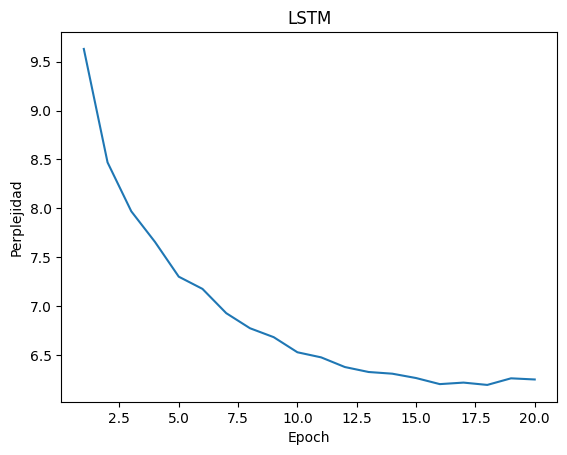

In [ ]:
epoch_count = range(1, len(history_ppl_lstm) + 1)

sns.lineplot(x=epoch_count, y=history_ppl_lstm)
plt.xlabel("Epoch")
plt.ylabel("Perplejidad")
plt.title("LSTM")
plt.show()

### Generación de secuencias

In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model("model_LSTM.keras")

In [ ]:
input_text='whenever it is a damp, drizzly'

generate_seq(model, input_text, max_length=max_context_size, n_words=60)

'whenever it is a damp, drizzly starbuck to the sailors of the sea of the sea of the sea of'

###  Beam search y muestreo aleatorio

In [ ]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="whenever it is a damp, drizzly")

In [ ]:
salidas[0]

array([43,  2, 38, 37, 38, 10, 38, 42, 45,  9, 17, 45,  9, 27, 45, 40, 45,
        8, 40, 22, 49,  7, 45,  8, 42,  9,  5,  5, 44, 33, 45, 21, 31, 45,
       17,  2, 38, 45, 43,  2, 40, 44, 38, 23, 27,  2,  9, 49,  7, 45, 40,
       37,  8, 45, 17,  2, 38, 42, 38,  7, 45, 40, 37,  8, 45, 17,  2, 38,
       42, 38,  7, 45, 40, 37,  8, 45, 17,  2, 38, 42, 38, 45, 43, 40, 27,
       45, 17,  2, 38, 45])

In [ ]:
# veamos las salidas
decode(salidas[0])

'whenever it is a damp, drizzly of the whale-ship, and there, and there, and there was the '

# GRU

### Definir el modelo

In [ ]:
from keras.layers import TimeDistributed, CategoryEncoding, GRU, Dense
from keras.models import Sequential

model = Sequential()

model.add(
    TimeDistributed(
        CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
        input_shape=(None, 1)
    )
)

model.add(
    GRU(
        200,
        return_sequences=True,
        dropout=0.1,
        recurrent_dropout=0.0 #Bajo acá también para reducir el tiempo de entrenamiento
    )
)

model.add(Dense(vocab_size, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 60)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       157,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 60)       │        12,060 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,260 (661.17 KB)

 Trainable params: 169,260 (661.17 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [ ]:
history_ppl_gru = []

start_time = time.time()

hist_gru = model.fit(
    X,
    y,
    epochs=20,
    callbacks=[
        PplCallback(
            tokenized_sentences_val,
            history_ppl_gru,
            patience=5,
            model_name="model_GRU.keras"
        )
    ],
    batch_size=256
)

end_time = time.time()

time_gru = end_time - start_time

print(f"Tiempo GRU: {time_gru:.2f} segundos")
print(f"Tiempo GRU: {time_gru/60:.2f} minutos")

Epoch 1/20
1265/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.5519
 mean perplexity: 7.880823750628365 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - loss: 2.2817
Epoch 2/20
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.9454
 mean perplexity: 6.737143272161484 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - loss: 1.8895
Epoch 3/20
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.7598
 mean perplexity: 6.285063601864708 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - loss: 1.7308
Epoch 4/20
1264/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.6592
 mean perplexity: 6.106446717182795 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - loss: 1.6408
Epoch 5/20
1264/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5942
 mean perplexity: 6.098949945635265 

Saved new model!
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - loss: 1.5810
Epoch 6/20
1265/1266 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5468
 mean

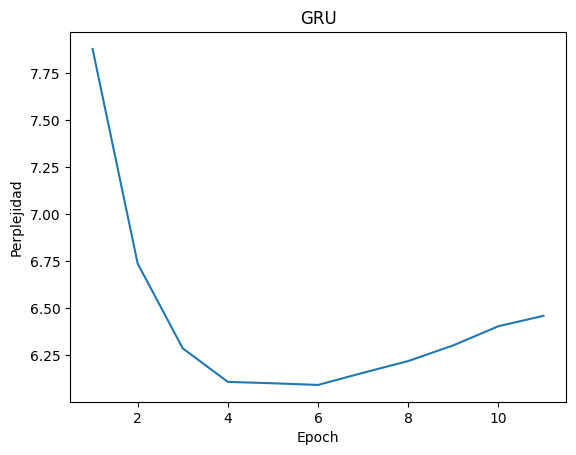

In [ ]:
epoch_count = range(1, len(history_ppl_gru) + 1)

sns.lineplot(x=epoch_count, y=history_ppl_gru)
plt.xlabel("Epoch")
plt.ylabel("Perplejidad")
plt.title("GRU")
plt.show()

### Generación de secuencias

In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model("model_GRU.keras")

In [ ]:
input_text='whenever it is a damp, drizzly'

generate_seq(model, input_text, max_length=max_context_size, n_words=60)

'whenever it is a damp, drizzly seemed to the large of the sea, and the streets of the sea,'

###  Beam search y muestreo aleatorio

In [ ]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="whenever it is a damp, drizzly")

In [ ]:
salidas[0]

array([43,  2, 38, 37, 38, 10, 38, 42, 45,  9, 17, 45,  9, 27, 45, 40, 45,
        8, 40, 22, 49,  7, 45,  8, 42,  9,  5,  5, 44, 33, 45, 54, 21, 22,
       22, 40, 37,  8, 38, 42, 27, 45, 21, 31, 45, 17,  2, 38, 45, 43,  2,
       40, 44, 38, 23, 27,  2,  9, 49,  7, 45, 40, 37,  8, 45, 17,  2, 38,
       37,  7, 45, 17,  2, 21, 30, 39,  2, 17, 45,  9, 45, 17,  2, 21, 30,
       39,  2, 17, 45,  9])

In [ ]:
# veamos las salidas
decode(salidas[0])

'whenever it is a damp, drizzly commanders of the whale-ship, and then, thought i thought i'

# Comparación entre los modelos

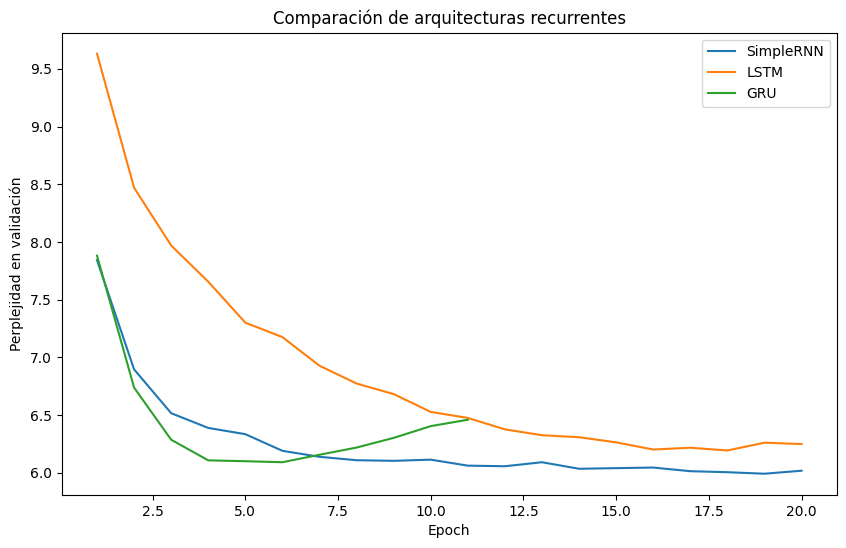

In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=range(1, len(history_ppl_simple) + 1),
    y=history_ppl_simple,
    label="SimpleRNN"
)

sns.lineplot(
    x=range(1, len(history_ppl_lstm) + 1),
    y=history_ppl_lstm,
    label="LSTM"
)

sns.lineplot(
    x=range(1, len(history_ppl_gru) + 1),
    y=history_ppl_gru,
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Perplejidad en validación")
plt.title("Comparación de arquitecturas recurrentes")
plt.legend()
plt.show()

In [ ]:
print("Mejor SimpleRNN:", min(history_ppl_simple))
print("Mejor LSTM:", min(history_ppl_lstm))
print("Mejor GRU:", min(history_ppl_gru))

Mejor SimpleRNN: 5.99049011071523
Mejor LSTM: 6.191960924201542
Mejor GRU: 6.090185820394092
